In [ ]:
# from pathlib import Path

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from matplotlib.colors import to_rgba

# import SimpleITK as sitk
# import ipywidgets as widgets
# from ipywidgets import interact
# from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.colors import to_rgba
import ipywidgets as widgets
from ipywidgets import interact

from ccf_roi_selector.atlas import load_atlas

In [4]:
repo_root = Path.cwd().parent
cache_dir = repo_root / "data" / "abc_atlas"

print(cache_dir)

c:\Users\maria.vergara\OneDrive - Allen Institute\Documents\Programming\abc-atlas-roi-selector\data\abc_atlas


In [5]:
cache_dir.mkdir(parents=True, exist_ok=True)

abc_cache = AbcProjectCache.from_cache_dir(cache_dir)

In [6]:
template_file = abc_cache.get_file_path(
    directory="Allen-CCF-2020",
    file_name="average_template_25"
)

annotation_file = abc_cache.get_file_path(
    directory="Allen-CCF-2020",
    file_name="annotation_25"
)

template_image = sitk.ReadImage(template_file)
annotation_image = sitk.ReadImage(annotation_file)

template = sitk.GetArrayFromImage(template_image)
annotation = sitk.GetArrayFromImage(annotation_image)

average_template_25.nii.gz: 100%|██████████| 33.0M/33.0M [00:01<00:00, 27.4MMB/s]  
annotation_25.nii.gz: 100%|██████████| 3.63M/3.63M [00:00<00:00, 18.1MMB/s]


In [7]:
parcellation_annotation = abc_cache.get_metadata_dataframe(
    directory="Allen-CCF-2020",
    file_name="parcellation_to_parcellation_term_membership"
)

parcellation_to_parcellation_term_membership.csv: 100%|██████████| 680k/680k [00:00<00:00, 3.80MMB/s] 


In [8]:
parcellation_annotation["parcellation_term_acronym"].unique()

array(['brain', 'grey', 'Isocortex', 'FRP', 'FRP1', 'FRP2/3', 'FRP5',
       'FRP6a', 'FRP6b', 'MOp', 'MOp1', 'MOp2/3', 'MOp5', 'MOp6a',
       'MOp6b', 'MOs', 'MOs1', 'MOs2/3', 'MOs5', 'MOs6a', 'MOs6b',
       'SSp-n', 'SSp-n1', 'SSp-n2/3', 'SSp-n4', 'SSp-n5', 'SSp-n6a',
       'SSp-n6b', 'SSp-bfd', 'SSp-bfd1', 'SSp-bfd2/3', 'SSp-bfd4',
       'SSp-bfd5', 'SSp-bfd6a', 'SSp-bfd6b', 'SSp-ll', 'SSp-ll1',
       'SSp-ll2/3', 'SSp-ll4', 'SSp-ll5', 'SSp-ll6a', 'SSp-ll6b', 'SSp-m',
       'SSp-m1', 'SSp-m2/3', 'SSp-m4', 'SSp-m5', 'SSp-m6a', 'SSp-m6b',
       'SSp-ul', 'SSp-ul1', 'SSp-ul2/3', 'SSp-ul4', 'SSp-ul5', 'SSp-ul6a',
       'SSp-ul6b', 'SSp-tr', 'SSp-tr1', 'SSp-tr2/3', 'SSp-tr4', 'SSp-tr5',
       'SSp-tr6a', 'SSp-tr6b', 'SSp-un', 'SSp-un1', 'SSp-un2/3',
       'SSp-un4', 'SSp-un5', 'SSp-un6a', 'SSp-un6b', 'SSs', 'SSs1',
       'SSs2/3', 'SSs4', 'SSs5', 'SSs6a', 'SSs6b', 'GU', 'GU1', 'GU2/3',
       'GU4', 'GU5', 'GU6a', 'GU6b', 'VISC', 'VISC1', 'VISC2/3', 'VISC4',
       'VISC5', 'V

In [9]:
def get_roi_indices(acronym):
    
    rows = parcellation_annotation[
        parcellation_annotation["parcellation_term_acronym"] == acronym
    ]
    
    if len(rows) == 0:
        print(f"Warning: ROI '{acronym}' not found.")
        return []
    
    return rows["parcellation_index"].unique()

In [10]:
def create_color_volume(annotation, roi_colors):
    
    rgba = np.zeros(annotation.shape + (4,), dtype=np.float32)

    for acronym, color in roi_colors.items():
        
        indices = get_roi_indices(acronym)
        
        mask = np.isin(annotation, indices)
        
        rgba[mask] = to_rgba(color)

    return rgba

In [11]:
roi_colors = {
    "VISp": "red",
    "STRd": "blue",
    "STRv": "cyan",
    "MOs": "orange",
    "MOp": "purple",
    "TH": "yellow",
}

In [12]:
colored_rois = create_color_volume(annotation, roi_colors)

In [13]:
def show_slice(volume, slice_index, axis=0, cmap="gray", title=None):
    """
    axis=0,1,2 para elegir en qué dimensión cortar
    """
    if axis == 0:
        img = volume[slice_index, :, :]
    elif axis == 1:
        img = volume[:, slice_index, :]
    elif axis == 2:
        img = volume[:, :, slice_index]
    else:
        raise ValueError("axis must be 0, 1, or 2")

    plt.figure(figsize=(6, 6))
    plt.imshow(img, cmap=cmap)
    plt.axis("off")
    
    if title is None:
        title = f"axis={axis}, slice={slice_index}"
    plt.title(title)
    plt.show()

In [14]:
def slice_to_plate(slice_index):
    return slice_index // 4 + 1

In [15]:
def show_overlay_slice(template, colored_rois, slice_index, axis=0):
    if axis == 0:
        axis_name = 'Sagittal'
        base = template[slice_index, :, :]
        overlay = colored_rois[slice_index, :, :, :]
        
    elif axis == 1:
        axis_name = 'Horizontal'
        base = template[:, slice_index, :]
        overlay = colored_rois[:, slice_index, :, :]
        
    elif axis == 2:
        axis_name = 'Coronal'
        base = template[:, :, slice_index]
        overlay = colored_rois[:, :, slice_index, :]
        
        # rotate 90 degrees
        base = np.rot90(base, k=3)
        overlay = np.rot90(overlay, k=3)

    else:
        raise ValueError("axis must be 0, 1, or 2")

    plate = slice_to_plate(slice_index)
    
    plt.figure(figsize=(8, 7))
    plt.imshow(base, cmap="gray")
    plt.imshow(overlay)
    plt.title(f"Atlas Plate {plate} | axis= {axis_name}")
    plt.axis("off")
    plt.show()

In [16]:
@interact(
    slice_index=widgets.IntSlider(
        min=0, 
        max=template.shape[0]-1, 
        step=1, value=209, 
        layout=widgets.Layout(width='700px')
        )
    )
def browse_overlay(slice_index):
    plate = slice_index // 4 + 1
    show_overlay_slice(
        template, 
        colored_rois, 
        slice_index=slice_index, 
        axis=2)
    print(f"Allen Atlas Plate: {plate}")

interactive(children=(IntSlider(value=209, description='slice_index', layout=Layout(width='700px'), max=455), …

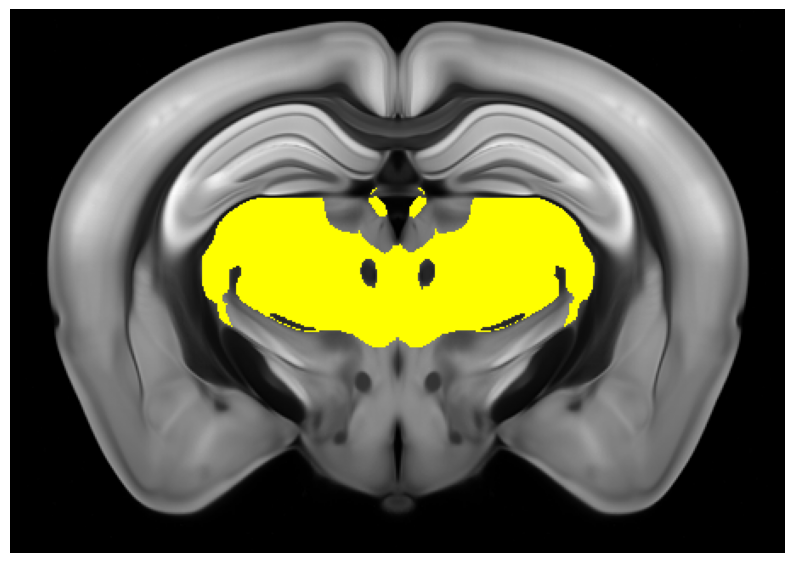

In [15]:
slice_index = 300

brain_slice = np.transpose(template[:, :, slice_index])
roi_slice = np.transpose(colored_rois[:, :, slice_index], (1, 0, 2))

plt.figure(figsize=(10, 8))

plt.imshow(brain_slice, cmap="gray")
plt.imshow(roi_slice)

plt.axis("off")
plt.show()

In [46]:
def find_roi(acronym):
    # Search full ontology
    full = parcellation_term[
        parcellation_term["acronym"].str.lower() == acronym.lower()
    ]

    # Search terms actually mapped to voxels
    mapped = parcellation_annotation[
        parcellation_annotation["parcellation_term_acronym"].str.lower()
        == acronym.lower()
    ]

    print(f"ROI: {acronym}")
    print(f"Found in full ontology: {len(full) > 0}")
    print(f"Found in mapped parcellations: {len(mapped) > 0}")

    if len(full):
        display(full[["acronym", "name", "identifier", "parent_identifier"]])

    if len(mapped):
        print(
            "Hierarchy level(s):",
            mapped["parcellation_term_set_name"].unique()
        )
        print(
            "Number of parcellations:",
            mapped["parcellation_index"].nunique()
        )